In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest


In [2]:
df = pd.read_csv("transacoes_anomalias.csv")

In [3]:
print(f"Primeira \n linha do dataset: {df.head()}")
print("\n")
print(df.head())

Primeira 
 linha do dataset:     valor  frequencia  tempo_entre_compras    categoria
0  169.87          13                  9.1    vestuario
1  144.47          18                  8.1  eletronicos
2  175.91           9                  9.7  alimentacao
3  210.92           5                 12.1  eletronicos
4  140.63           7                  6.4  alimentacao


    valor  frequencia  tempo_entre_compras    categoria
0  169.87          13                  9.1    vestuario
1  144.47          18                  8.1  eletronicos
2  175.91           9                  9.7  alimentacao
3  210.92           5                 12.1  eletronicos
4  140.63           7                  6.4  alimentacao


In [4]:
print(f"Informação do dataset: {df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   valor                100 non-null    float64
 1   frequencia           100 non-null    int64  
 2   tempo_entre_compras  100 non-null    float64
 3   categoria            100 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ KB
Informação do dataset: None


In [5]:
# Seleção das features numericas
feature = ["valor","frequencia","tempo_entre_compras"]
X = df[feature]

In [6]:
#Padronização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
#Treinamento do isolation forest
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

In [8]:
model.fit(X_scaled)

IsolationForest(contamination=0.05, random_state=42)

In [9]:
#Predições de anomalias
# -1 para anomalia / 1 para normal
df['anomaly'] = model.predict(X_scaled)

In [10]:
#Score de anomali(quanto menor, mais anormal ou anomalia)
df["anomaly_score"] = model.decision_function(X_scaled)

In [11]:
#Rotulo mais legivel
df["anomaly_label"] = df["anomaly"].map({1 : "normal" , -1: "anômalo"})

In [12]:
#Quantidade de registros encontrados
print(f"Registros por classes: {df['anomaly_label'].value_counts()}")

Registros por classes: anomaly_label
normal     95
anômalo     5
Name: count, dtype: int64


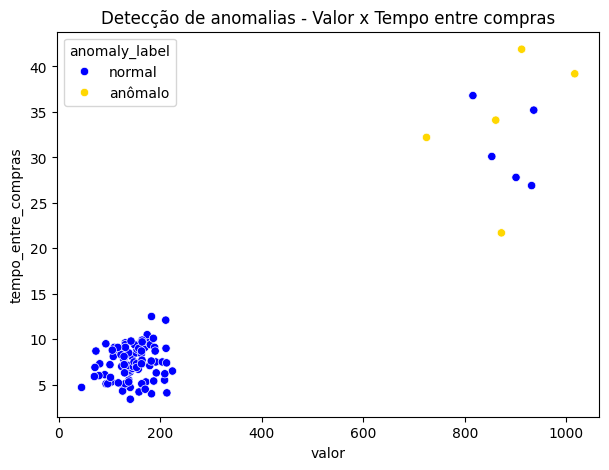

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x = "valor",
    y = "tempo_entre_compras",
    hue = "anomaly_label",
    palette = {"normal": "blue", "anômalo" : "gold"}
)
plt.title("Detecção de anomalias - Valor x Tempo entre compras")
plt.show()

In [14]:
#Nova colunas dos graficos das anomalia da transações anomalias
df

,valor,frequencia,tempo_entre_compras,categoria,anomaly,anomaly_score,anomaly_label
0,169.87,13,9.1,vestuario,1,0.225578,normal
1,144.47,18,8.1,eletronicos,1,0.171155,normal
2,175.91,9,9.7,alimentacao,1,0.210789,normal
3,210.92,5,12.1,eletronicos,1,0.065115,normal
4,140.63,7,6.4,alimentacao,1,0.222987,normal
...,...,...,...,...,...,...,...
95,724.38,1,32.2,alimentacao,-1,-0.026760,anômalo
96,935.53,2,35.2,eletronicos,1,0.022994,normal
97,931.33,2,26.9,eletronicos,1,0.003655,normal
98,900.61,1,27.8,eletronicos,1,0.039665,normal


In [15]:
# from google.colab import sheets
# sheet = sheets.InteractiveSheet(df=df)

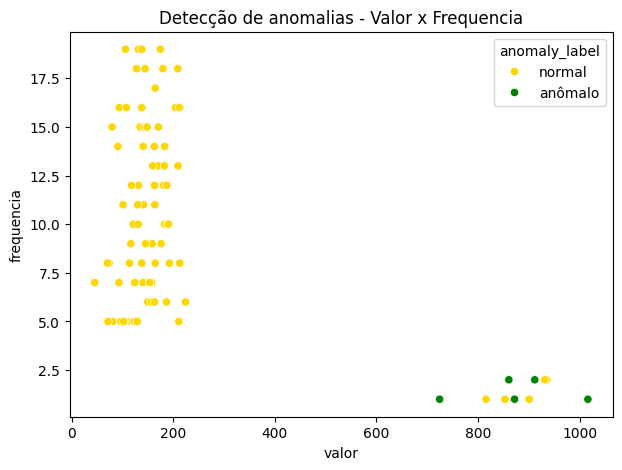

In [16]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data = df,
    x = "valor",
    y = "frequencia",
    hue = "anomaly_label",
    palette = {"normal" : "gold", "anômalo" : "green"}
)
plt.title("Detecção de anomalias - Valor x Frequencia")
plt.show()